In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [39]:
df = pd.read_csv('Air_Traffic_Passenger_Statistics.csv')
df

,index,Activity Period,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count,Adjusted Activity Type Code,Adjusted Passenger Count,Year,Month
0,0,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271,Deplaned,27271,2005,July
1,1,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,29131,Enplaned,29131,2005,July
2,2,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,5415,Thru / Transit * 2,10830,2005,July
3,3,200507,Air Canada,AC,Air Canada,AC,International,Canada,Deplaned,Other,Terminal 1,B,35156,Deplaned,35156,2005,July
4,4,200507,Air Canada,AC,Air Canada,AC,International,Canada,Enplaned,Other,Terminal 1,B,34090,Enplaned,34090,2005,July
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15002,15002,201603,Virgin America,VX,Virgin America,VX,Domestic,US,Enplaned,Low Fare,Terminal 2,D,194636,Enplaned,194636,2016,March
15003,15003,201603,Virgin America,VX,Virgin America,VX,International,Mexico,Deplaned,Low Fare,International,A,4189,Deplaned,4189,2016,March
15004,15004,201603,Virgin America,VX,Virgin America,VX,International,Mexico,Enplaned,Low Fare,Terminal 2,D,4693,Enplaned,4693,2016,March
15005,15005,201603,Virgin Atlantic,VS,Virgin Atlantic,VS,International,Europe,Deplaned,Other,International,A,12313,Deplaned,12313,2016,March


In [40]:
df.isnull().sum()

index                           0
Activity Period                 0
Operating Airline               0
Operating Airline IATA Code    54
Published Airline               0
Published Airline IATA Code    54
GEO Summary                     0
GEO Region                      0
Activity Type Code              0
Price Category Code             0
Terminal                        0
Boarding Area                   0
Passenger Count                 0
Adjusted Activity Type Code     0
Adjusted Passenger Count        0
Year                            0
Month                           0
dtype: int64

In [41]:
# Mostra todas as linhas que possuem PELO MENOS UM valor nulo em qualquer coluna
linhas_com_nulos = df[df.isnull().any(axis=1)]

# Exibe as primeiras 20 linhas encontradas
print(linhas_com_nulos.head(20))

      index  Activity Period Operating Airline Operating Airline IATA Code  \
148     148           200508    Boeing Company                         NaN   
6814   6814           201005         Servisair                         NaN   
6815   6815           201005         Servisair                         NaN   
6925   6925           201006  Pacific Aviation                         NaN   
6926   6926           201006  Pacific Aviation                         NaN   
7173   7173           201008         Servisair                         NaN   
7174   7174           201008         Servisair                         NaN   
7747   7747           201101         Servisair                         NaN   
7748   7748           201101         Servisair                         NaN   
7972   7972           201103         Servisair                         NaN   
7973   7973           201103         Servisair                         NaN   
8327   8327           201106         Servisair                  

In [42]:
df['Operating Airline IATA Code'] = df['Operating Airline IATA Code'].fillna("OTH")
df['Published Airline IATA Code'] = df['Published Airline IATA Code'].fillna("OTH")

In [43]:
df.isnull().sum()

index                          0
Activity Period                0
Operating Airline              0
Operating Airline IATA Code    0
Published Airline              0
Published Airline IATA Code    0
GEO Summary                    0
GEO Region                     0
Activity Type Code             0
Price Category Code            0
Terminal                       0
Boarding Area                  0
Passenger Count                0
Adjusted Activity Type Code    0
Adjusted Passenger Count       0
Year                           0
Month                          0
dtype: int64

In [44]:
df.duplicated().sum()

np.int64(0)

In [45]:
# Convert 202301 to a real date (01/01/2023)
df['Date'] = pd.to_datetime(df['Activity Period'], format='%Y%m')

# Extract year and month to facilitate the filter in Tableau
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()

In [46]:
df.head()

,index,Activity Period,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count,Adjusted Activity Type Code,Adjusted Passenger Count,Year,Month,Date
0,0,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271,Deplaned,27271,2005,July,2005-07-01
1,1,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,29131,Enplaned,29131,2005,July,2005-07-01
2,2,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,5415,Thru / Transit * 2,10830,2005,July,2005-07-01
3,3,200507,Air Canada,AC,Air Canada,AC,International,Canada,Deplaned,Other,Terminal 1,B,35156,Deplaned,35156,2005,July,2005-07-01
4,4,200507,Air Canada,AC,Air Canada,AC,International,Canada,Enplaned,Other,Terminal 1,B,34090,Enplaned,34090,2005,July,2005-07-01


In [47]:
# Removing empty espaces and standard the title
df['Operating Airline'] = df['Operating Airline'].str.strip().str.title()
df['Published Airline'] = df['Published Airline'].str.strip().str.title()

In [48]:
df['GEO Region'].unique()

array(['US', 'Canada', 'Asia', 'Europe', 'Australia / Oceania', 'Mexico',
       'Central America', 'Middle East', 'South America'], dtype=object)

In [49]:
# Creating a group of macro regions

def agrupar_mercado(regiao):
    if regiao == 'US':
        return 'Domestic'
    elif regiao in ['Central America', 'South America', 'Mexico', 'Canada']:
        return 'Americas (Excl. US)'
    elif regiao in ['Asia', 'Middle East']:
        return 'Asia & Middle East'
    elif regiao == 'Europe':
        return 'Europe'
    elif regiao in ['Australia / Oceania']:
        return 'Oceania'
    else:
        return 'Other'

# Creating a new column
df['Market_Segment'] = df['GEO Region'].apply(agrupar_mercado)

# Creating a binare column: domestic vs international
df['Is_International'] = df['GEO Region'].apply(lambda x: 'International' if x != 'US' else 'Domestic')


In [50]:
df.head(30)

,index,Activity Period,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count,Adjusted Activity Type Code,Adjusted Passenger Count,Year,Month,Date,Market_Segment,Is_International
0,0,200507,Ata Airlines,TZ,Ata Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271,Deplaned,27271,2005,July,2005-07-01,Domestic,Domestic
1,1,200507,Ata Airlines,TZ,Ata Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,29131,Enplaned,29131,2005,July,2005-07-01,Domestic,Domestic
2,2,200507,Ata Airlines,TZ,Ata Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,5415,Thru / Transit * 2,10830,2005,July,2005-07-01,Domestic,Domestic
3,3,200507,Air Canada,AC,Air Canada,AC,International,Canada,Deplaned,Other,Terminal 1,B,35156,Deplaned,35156,2005,July,2005-07-01,Americas (Excl. US),International
4,4,200507,Air Canada,AC,Air Canada,AC,International,Canada,Enplaned,Other,Terminal 1,B,34090,Enplaned,34090,2005,July,2005-07-01,Americas (Excl. US),International
5,5,200507,Air China,CA,Air China,CA,International,Asia,Deplaned,Other,International,G,6263,Deplaned,6263,2005,July,2005-07-01,Asia & Middle East,International
6,6,200507,Air China,CA,Air China,CA,International,Asia,Enplaned,Other,International,G,5500,Enplaned,5500,2005,July,2005-07-01,Asia & Middle East,International
7,7,200507,Air France,AF,Air France,AF,International,Europe,Deplaned,Other,International,A,12050,Deplaned,12050,2005,July,2005-07-01,Europe,International
8,8,200507,Air France,AF,Air France,AF,International,Europe,Enplaned,Other,International,A,11638,Enplaned,11638,2005,July,2005-07-01,Europe,International
9,9,200507,Air New Zealand,NZ,Air New Zealand,NZ,International,Australia / Oceania,Deplaned,Other,International,G,4998,Deplaned,4998,2005,July,2005-07-01,Oceania,International


In [51]:
df['Published Airline'].unique()

array(['Ata Airlines', 'Air Canada', 'Air China', 'Air France',
       'Air New Zealand', 'Airtran Airways', 'Alaska Airlines',
       'All Nippon Airways', 'American Airlines', 'Asiana Airlines',
       'Delta Air Lines', 'Belair Airlines', 'British Airways',
       'Cathay Pacific', 'China Airlines', 'Eva Airways',
       'Frontier Airlines', 'Hawaiian Airlines', 'Icelandair',
       'Independence Air', 'Japan Airlines', 'Klm Royal Dutch Airlines',
       'Korean Air Lines', 'Lufthansa German Airlines', 'Us Airways',
       'Mexicana Airlines', 'Midwest Airlines', 'Northwest Airlines',
       'Philippine Airlines', 'Singapore Airlines',
       'United Airlines - Pre 07/01/2013', 'Sun Country Airlines', 'Taca',
       'United Airlines', 'Virgin Atlantic', 'Westjet Airlines',
       'Boeing Company', 'Miami Air International', 'Qantas Airways',
       'Ameriflight', 'Spirit Airlines', 'Xtra Airways',
       'Evergreen International Airlines', 'Aeromexico',
       'Jetblue Airways', 'So

In [52]:
df['Operating Airline IATA Code'].unique()

array(['TZ', 'AC', 'CA', 'AF', 'NZ', 'FL', 'AS', 'NH', 'AA', 'MQ', 'OZ',
       'EV', '4T', 'BA', 'CX', 'CI', 'DL', 'BR', 'F9', 'HA', 'QX', 'FI',
       'DH', 'JL', 'KL', 'KE', 'LH', 'YV', 'MX', 'YX', 'NW', 'PR', 'SQ',
       'OO', 'SY', 'TA', 'US ', 'UA', 'VS', 'WS', 'OTH', 'GL', 'QK', 'QF',
       'A8', 'NK', 'XP', 'EZ', 'AM', 'B6', 'XE', 'WN', 'VX', 'EI', 'G4',
       '9W', 'BBB', 'EK', 'XJ', 'WO', 'AB', 'RW', 'LX', 'LP', 'SE', 'MU',
       'SK', '5Y', 'CP', 'EY', 'CZ', 'TK', 'CM', 'AI'], dtype=object)

In [53]:
# Changind 'United Airlines - Pre 07/01/2013' to United Airlines
df['Operating Airline'] = df['Operating Airline'].replace('United Airlines - Pre 07/01/2013', 'United Airlines')
df['Published Airline'] = df['Published Airline'].replace('United Airlines - Pre 07/01/2013', 'United Airlines')

In [54]:
df['Published Airline'].unique()

array(['Ata Airlines', 'Air Canada', 'Air China', 'Air France',
       'Air New Zealand', 'Airtran Airways', 'Alaska Airlines',
       'All Nippon Airways', 'American Airlines', 'Asiana Airlines',
       'Delta Air Lines', 'Belair Airlines', 'British Airways',
       'Cathay Pacific', 'China Airlines', 'Eva Airways',
       'Frontier Airlines', 'Hawaiian Airlines', 'Icelandair',
       'Independence Air', 'Japan Airlines', 'Klm Royal Dutch Airlines',
       'Korean Air Lines', 'Lufthansa German Airlines', 'Us Airways',
       'Mexicana Airlines', 'Midwest Airlines', 'Northwest Airlines',
       'Philippine Airlines', 'Singapore Airlines', 'United Airlines',
       'Sun Country Airlines', 'Taca', 'Virgin Atlantic',
       'Westjet Airlines', 'Boeing Company', 'Miami Air International',
       'Qantas Airways', 'Ameriflight', 'Spirit Airlines', 'Xtra Airways',
       'Evergreen International Airlines', 'Aeromexico',
       'Jetblue Airways', 'Southwest Airlines', 'Virgin America',
      

In [55]:
df['Terminal'].unique()

array(['Terminal 1', 'International', 'Terminal 3', 'Other', 'Terminal 2'],
      dtype=object)

In [56]:
df_final = df.drop(['index', 'Activity Period','GEO Summary'], axis = 1)
df_final.head()

,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count,Adjusted Activity Type Code,Adjusted Passenger Count,Year,Month,Date,Market_Segment,Is_International
0,Ata Airlines,TZ,Ata Airlines,TZ,US,Deplaned,Low Fare,Terminal 1,B,27271,Deplaned,27271,2005,July,2005-07-01,Domestic,Domestic
1,Ata Airlines,TZ,Ata Airlines,TZ,US,Enplaned,Low Fare,Terminal 1,B,29131,Enplaned,29131,2005,July,2005-07-01,Domestic,Domestic
2,Ata Airlines,TZ,Ata Airlines,TZ,US,Thru / Transit,Low Fare,Terminal 1,B,5415,Thru / Transit * 2,10830,2005,July,2005-07-01,Domestic,Domestic
3,Air Canada,AC,Air Canada,AC,Canada,Deplaned,Other,Terminal 1,B,35156,Deplaned,35156,2005,July,2005-07-01,Americas (Excl. US),International
4,Air Canada,AC,Air Canada,AC,Canada,Enplaned,Other,Terminal 1,B,34090,Enplaned,34090,2005,July,2005-07-01,Americas (Excl. US),International


In [57]:
df_final.to_csv('Air_Traffic_Passenger_Statistics_clean_tableau.csv', index=False, encoding='utf-8-sig', sep=',')

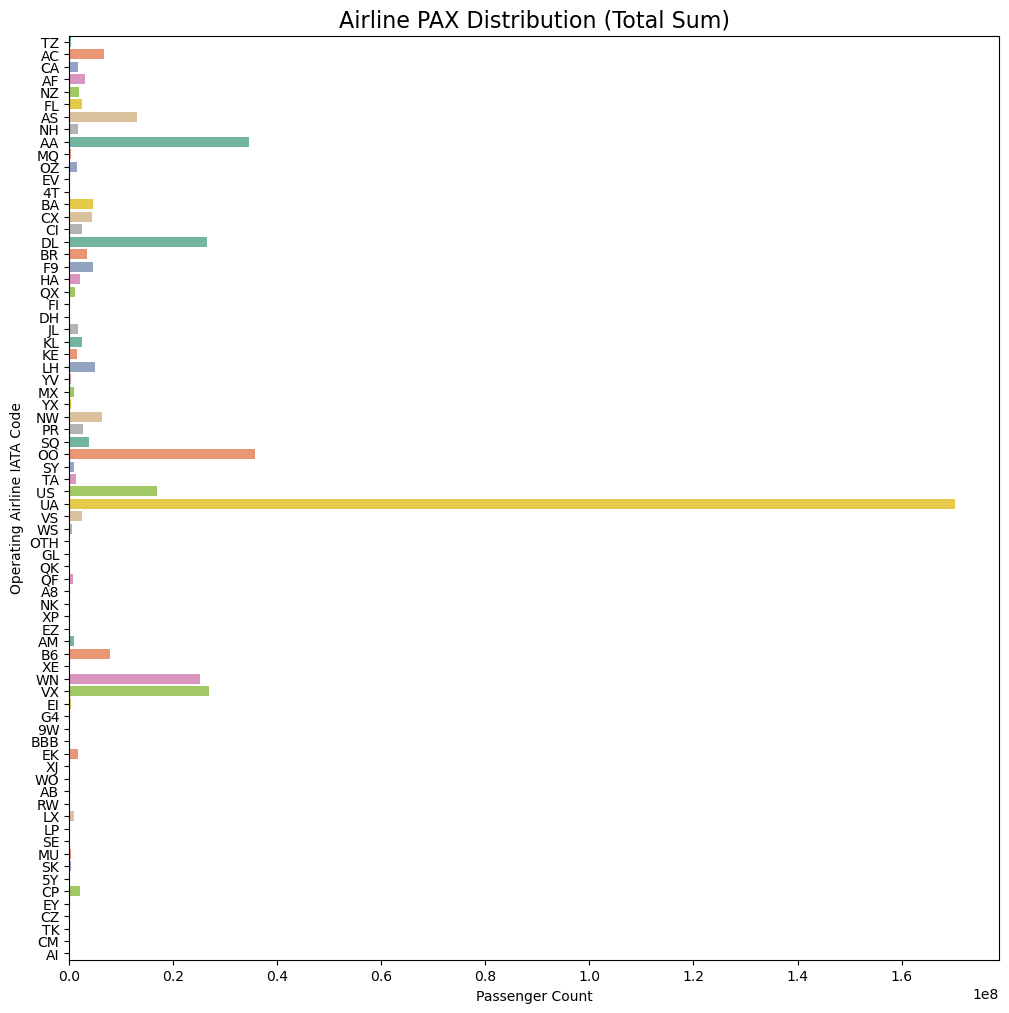

In [58]:
# Creating barplot
plt.figure(figsize=(12, 12))
plot = sns.barplot(data=df_final, 
                   x='Passenger Count', 
                   y='Operating Airline IATA Code', 
                   palette="Set2", 
                   estimator=np.sum, 
                   errorbar=None)    

plt.title('Airline PAX Distribution (Total Sum)', fontsize=16)
plt.show()

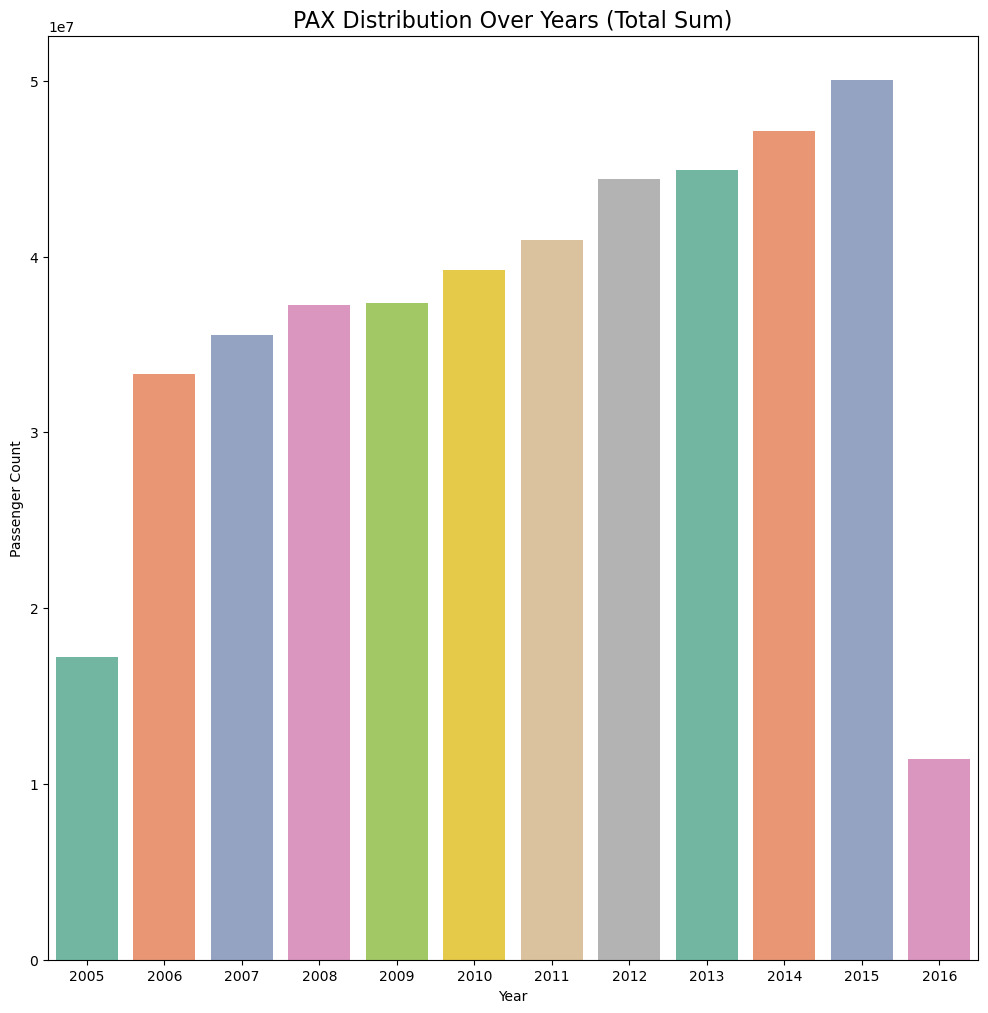

In [59]:
# Creating barplot
plt.figure(figsize=(12, 12))
plot = sns.barplot(data=df_final, 
                   x='Year', 
                   y='Passenger Count', 
                   palette="Set2", 
                   estimator=np.sum, 
                   errorbar=None)    

plt.title('PAX Distribution Over Years (Total Sum)', fontsize=16)
plt.show()

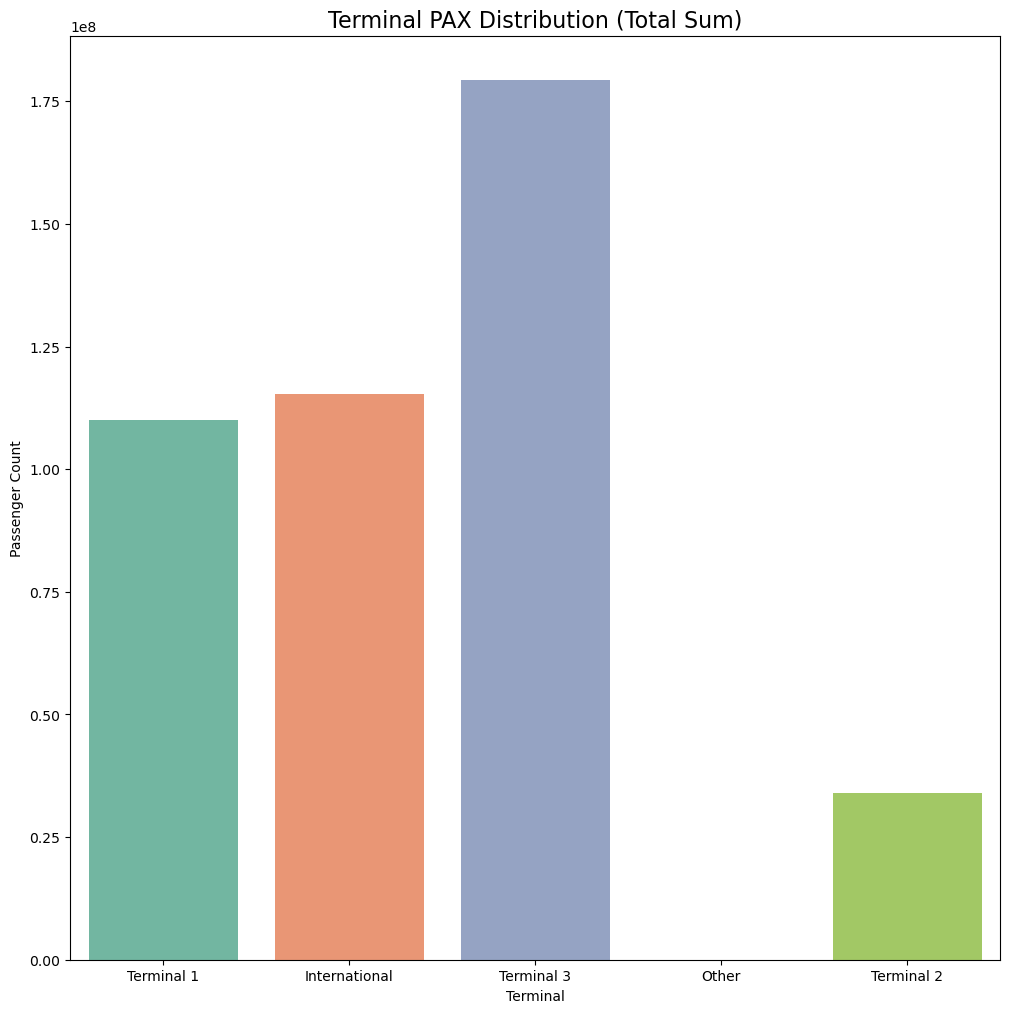

In [60]:
# Creating barplot
plt.figure(figsize=(12, 12))
plot = sns.barplot(data=df_final, 
                   x='Terminal', 
                   y='Passenger Count', 
                   palette="Set2", 
                   estimator=np.sum, 
                   errorbar=None)    

plt.title('Terminal PAX Distribution (Total Sum)', fontsize=16)
plt.show()

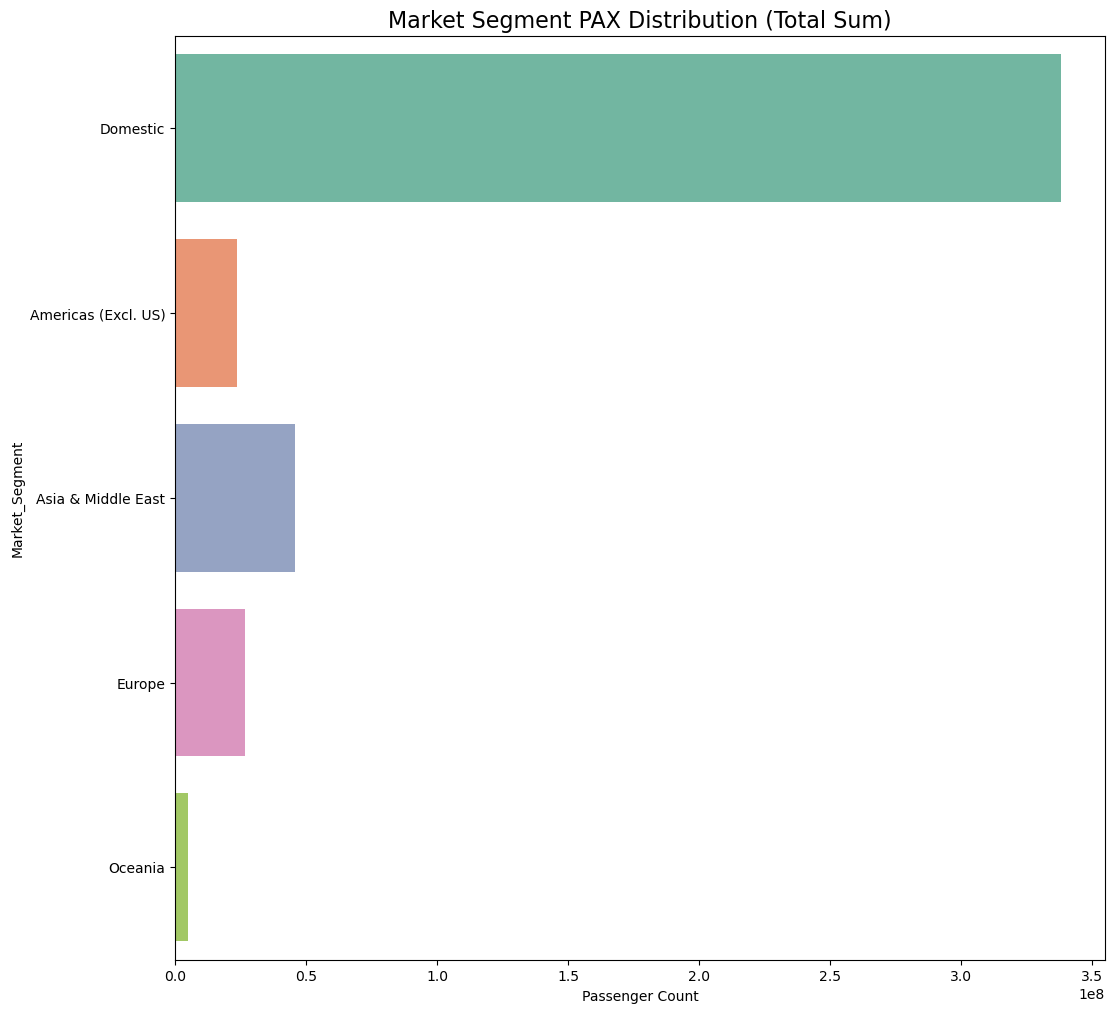

In [61]:
# Creating barplot
plt.figure(figsize=(12, 12))
plot = sns.barplot(data=df_final, 
                   x='Passenger Count', 
                   y='Market_Segment', 
                   palette="Set2", 
                   estimator=np.sum, 
                   errorbar=None)    

plt.title('Market Segment PAX Distribution (Total Sum)', fontsize=16)
plt.show()

In [67]:
df_final["Market_Segment"].unique()

array(['Domestic', 'Americas (Excl. US)', 'Asia & Middle East', 'Europe',
       'Oceania'], dtype=object)

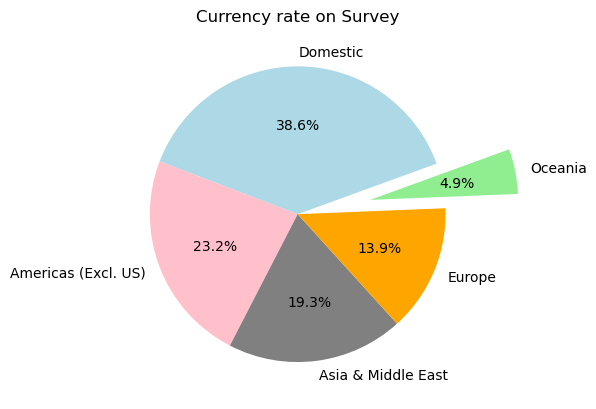

In [69]:
market_segment = df_final["Market_Segment"].value_counts()
labels = ['Domestic','Americas (Excl. US)','Asia & Middle East','Europe','Oceania']
colors=['lightblue','pink', 'grey', 'orange', 'lightgreen', 'yellow']
explode=[0, 0, 0, 0, 0.5]
plt.pie(market_segment, explode=explode, labels = labels, colors=colors, autopct="%1.1f%%", startangle=20)
plt.title("Currency rate on Survey")
plt.show()

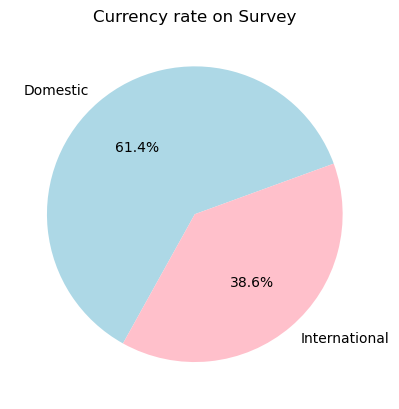

In [70]:
is_international_segment = df_final["Is_International"].value_counts()
labels = ['Domestic','International']
colors=['lightblue','pink']
plt.pie(is_international_segment, labels = labels, colors=colors, autopct="%1.1f%%", startangle=20)
plt.title("Currency rate on Survey")
plt.show()